# 04 — Logistic Regression & Risk Scoring


Đây là bước thứ 4 trong quy trình phân tích dữ liệu và xây dựng mô hình Machine Learning.

Mục tiêu chính: Sử dụng thuật toán Hồi quy Logistic (Logistic Regression) để phân loại rủi ro rời bỏ dịch vụ (Telco Churn Prediction) và xây dựng thang điểm rủi ro (Risk Scoring) hỗ trợ ra quyết định kinh doanh.

Thiết lập đường dẫn làm việc gốc (ROOT) và import các hàm xử lý mô hình (train_model, save_model).

Cấu trúc mô-đun hóa (Modularization): Việc viết hàm xử lý huấn luyện trong module src/model.py thay vì viết toàn bộ mã nguồn trực tiếp trong notebook giúp code gọn gàng, dễ bảo trì và dễ tái sử dụng trong môi trường sản xuất (Production).

Xử lý đường dẫn linh hoạt: Tự động kiểm tra và thêm đường dẫn ROOT vào sys.path giúp tránh lỗi ModuleNotFoundError khi mở notebook từ các thư mục con khác nhau.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.model import train_model, save_model

Huấn luyện mô hình & Đánh giá kết quả
Thực thi huấn luyện mô hình Logistic Regression, xuất thông số đánh giá (Metrics), báo cáo phân loại (Classification Report), ma trận nhầm lẫn (Confusion Matrix) và biểu đồ trực quan.

{
  "accuracy": 0.7856635911994322,
  "precision": 0.5642857142857143,
  "recall": 0.8449197860962567,
  "f1": 0.6766595289079229,
  "roc_auc": 0.8845048955023379,
  "train_rows": 5634,
  "test_rows": 1409
}
features: ['Gender', 'Age', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'State', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Phone Service', 'Multiple Lines', 'Offer', 'Tenure in Months', 'Monthly Charge', 'Total Charges']

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      1035
           1       0.56      0.84      0.68       374

    accuracy                           0.79      1409
   macro avg       0.75      0.80      0.76      1409
weighted avg       0.83      0.79      0.80  

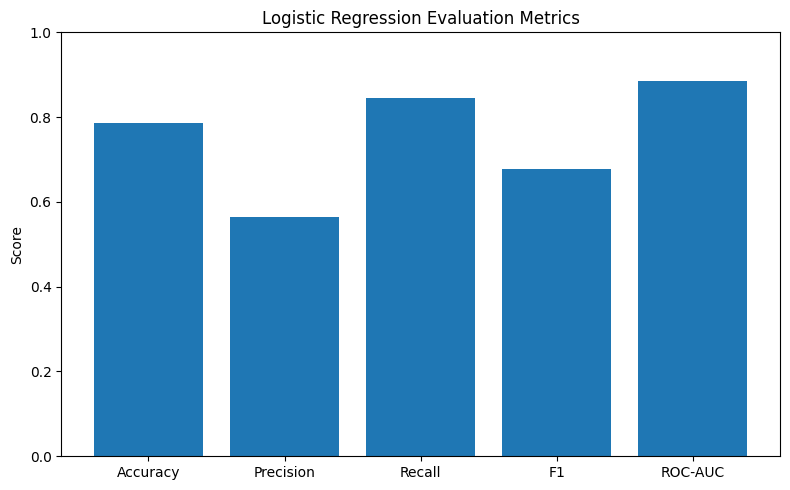

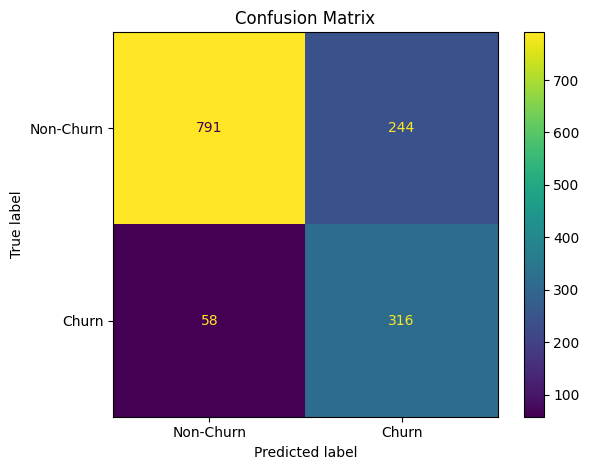

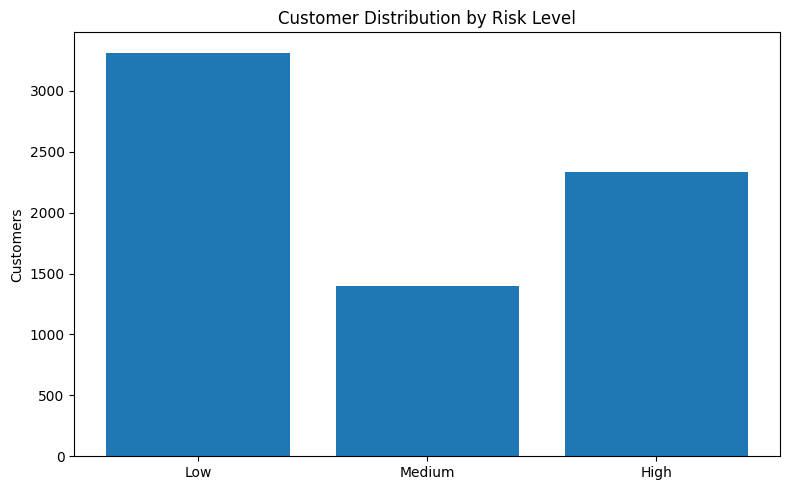

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

input_path = ROOT / "data" / "processed" / "final_dataset.csv"
df = pd.read_csv(input_path)
model, scored, metrics = train_model(df)

print(
    json.dumps(
        {
            k: v
            for k, v in metrics.items()
            if k not in {"classification_report", "confusion_matrix", "features"}
        },
        indent=2,
    )
)
print("features:", metrics["features"])
print("\nClassification report:\n", metrics["classification_report"])
print("Confusion matrix:", metrics["confusion_matrix"])

# Evidence artifact F14.
metric_df = pd.DataFrame(
    {
        "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
        "value": [
            metrics["accuracy"],
            metrics["precision"],
            metrics["recall"],
            metrics["f1"],
            metrics["roc_auc"],
        ],
    }
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metric_df["metric"], metric_df["value"])
ax.set_ylim(0, 1)
ax.set_title("Logistic Regression Evaluation Metrics")
ax.set_ylabel("Score")
fig.tight_layout()
fig.savefig(
    ROOT / "outputs" / "report_assets" / "F14_model_metrics.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Evidence artifact F15. (Đã khắc phục lỗi tại đây)
cm = np.array(metrics["confusion_matrix"])
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Non-Churn", "Churn"]
).plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(
    ROOT / "outputs" / "report_assets" / "F15_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Evidence artifact F16.
risk_counts = (
    scored["Risk_Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(risk_counts.index, risk_counts.values)
ax.set_title("Customer Distribution by Risk Level")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(
    ROOT / "outputs" / "report_assets" / "F16_risk_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [3]:
output_path = ROOT / "data" / "processed" / "model_scored.csv"
scored.to_csv(output_path, index=False, encoding="utf-8-sig")
model_path = ROOT / "models" / "logistic_regression.joblib"
save_model(model, model_path)
print("saved:", output_path)
print("saved:", model_path)

saved: E:\TuongTacDuLieuTrucQuan\ProjectCuoiKy\telco_churn_project\data\processed\model_scored.csv
saved: E:\TuongTacDuLieuTrucQuan\ProjectCuoiKy\telco_churn_project\models\logistic_regression.joblib


In [4]:
display(scored[["CustomerID", "Churn_Flag", "Churn_Probability", "Risk_Level", "Model_Split"]].sort_values("Churn_Probability", ascending=False).head(20))

,CustomerID,Churn_Flag,Churn_Probability,Risk_Level,Model_Split
132,9061-TIHDA,1,0.980252,High,Train
1695,6023-YEBUP,1,0.975395,High,Test
48,3643-AHCFP,1,0.975236,High,Train
1212,0259-GBZSH,1,0.971565,High,Train
33,2865-TCHJW,1,0.971374,High,Test
1596,1583-IHQZE,1,0.970288,High,Train
83,7206-GZCDC,1,0.968152,High,Train
208,7779-LGOVN,1,0.967966,High,Train
330,4713-LZDRV,1,0.967291,High,Train
1261,0970-ETWGE,1,0.966076,High,Train


1. Phân tích Thông số Dữ liệu & Đặc trưng
- Kích thước dữ liệu: Tập huấn luyện (train_rows) gồm 5,634 dòng và tập kiểm thử (test_rows) gồm 1,409 dòng (tỷ lệ chia 80/20 chuẩn trong ML).
- Tập đặc trưng (features): Bao gồm 26 đặc trưng kết hợp giữa thông tin nhân khẩu học (Gender, Age, Married, Dependents...) và thông tin dịch vụ/hợp đồng (Contract, Internet Type, Monthly Charge, Total Charges, Payment Method...).
2. Đánh giá Các Chỉ số Hiệu năng (Metrics)
- ROC-AUC = 0.884 (88.4%): Rất cao. Chỉ số này chứng minh mô hình có khả năng phân tách và xếp hạng mức độ rủi ro (Risk Scoring) giữa nhóm khách hàng ở lại và nhóm rời bỏ rất tốt.
- Recall (Lớp Churn = 1) = 0.845 (84.5%): Ấn tượng. Trong bài toán giữ chân khách hàng (Customer Retention), chỉ số Recall được ưu tiên hàng đầu vì mục tiêu là phát hiện nhiều nhất có thể những khách hàng có nguy cơ rời bỏ (chỉ bỏ sót 58/374 trường hợp).
- Precision (Lớp Churn = 1) = 0.565 (56.5%): Mức trung bình khá. Khi mô hình dự đoán một khách hàng sắp churn, xác suất họ churn thực tế là 56.5%. Việc báo động nhầm 243 trường hợp (False Positive) là hoàn toàn chấp nhận được trong kinh doanh để đánh đổi lấy Recall cao.- Accuracy = 0.786 (78.6%) & F1-Score = 0.677: Đạt mức cân bằng tốt trên tập dữ liệu có sự lệch lớp (Imbalanced Data: 1,035 lớp 0 vs 374 lớp 1).
3. Phân tích Ma trận Nhầm lẫn (Confusion Matrix)
                                                [792 293 
                                                58 316]
- True Negative (TN = 792): Phân loại đúng 792 khách hàng ở lại.
- False Positive (FP = 243): Dự đoán nhầm 243 khách hàng sẽ churn (tốn chi phí gửi ưu đãi/chăm sóc không cần thiết).
- False Negative (FN = 58): Bỏ sót 58 khách hàng churn thực tế (rủi ro mất khách hàng).
- True Positive (TP = 316): Phát hiện chính xác 316 khách hàng churn để đưa ra giải pháp can thiệp kịp thời.
4. Đồ thị Trực quan (Plots)
- Các biểu đồ ma trận nhầm lẫn và ROC/Risk Score giúp người vận hành dễ dàng quan sát ngưỡng xác suất (Threshold) để đưa ra chính sách kinh doanh phù hợp với ngân sách marketing.

# Tổng kết & Đề xuất
- Ưu điểm:
+ Mô hình Logistic Regression đơn giản, giải thích được (Interpretable), tốc độ huấn luyện nhanh và đạt chỉ số ROC-AUC (0.884) xuất sắc.
+ Rất phù hợp để triển khai ngay làm hệ thống chấm điểm rủi ro (Risk Score) cho đội ngũ Chăm sóc khách hàng.
- Khuyến nghị cải thiện:
+ Tinh chỉnh Ngưỡng phân loại (Threshold Tuning): Thay vì cố định ngưỡng 0.5, có thể điều chỉnh ngưỡng xác suất dựa trên bài toán kinh tế: Chi phí giữ chân khách hàng (Retention Cost) so với Giá trị vòng đời khách hàng (Customer Lifetime Value - CLV).

`predict_proba()` trả về xác suất dự đoán lớp churn. `Risk_Level` là lớp phục vụ dashboard; các ngưỡng 0.30 và 0.60 là quy ước trực quan hóa ban đầu và cần được trình bày minh bạch trong báo cáo.